In [139]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from anastruct import SystemElements

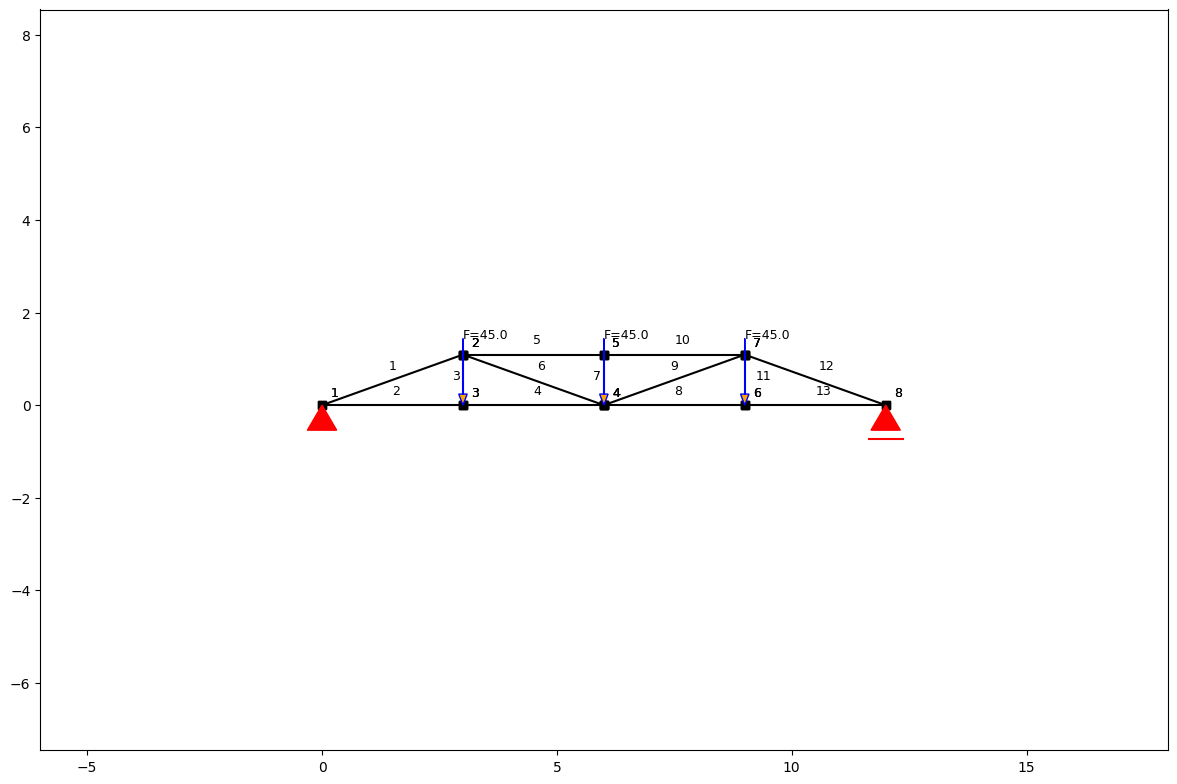

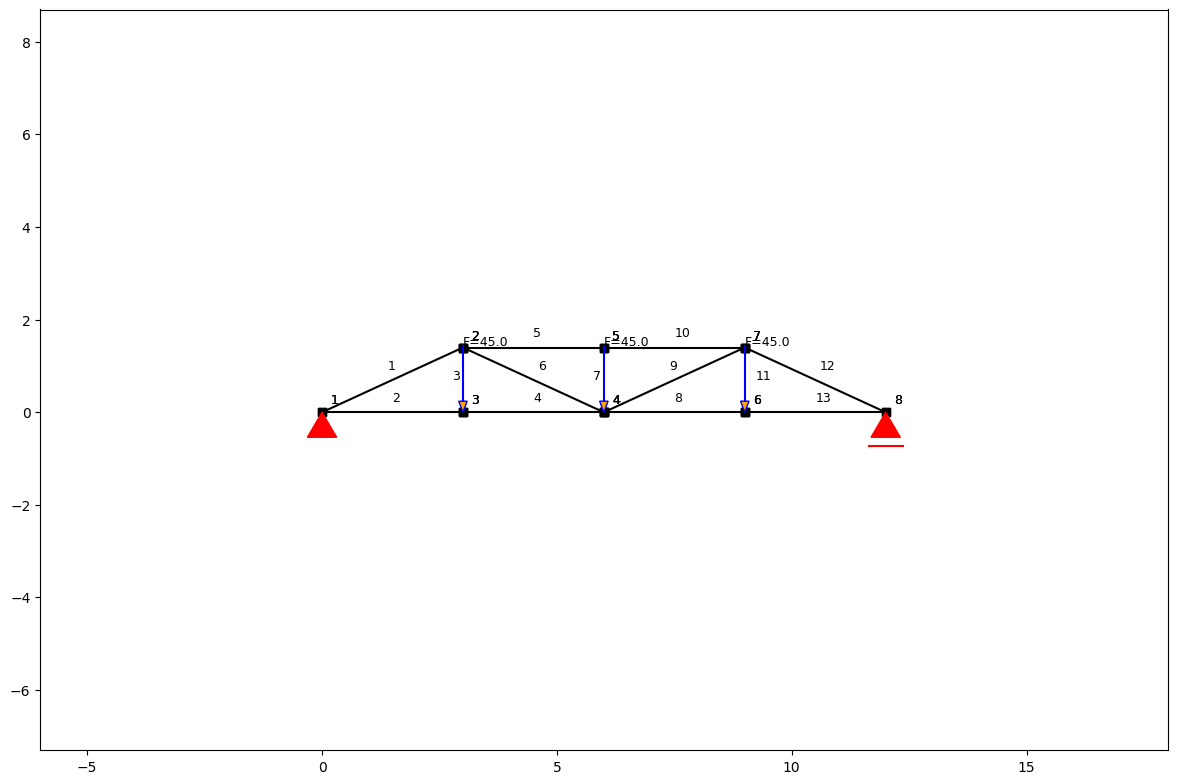

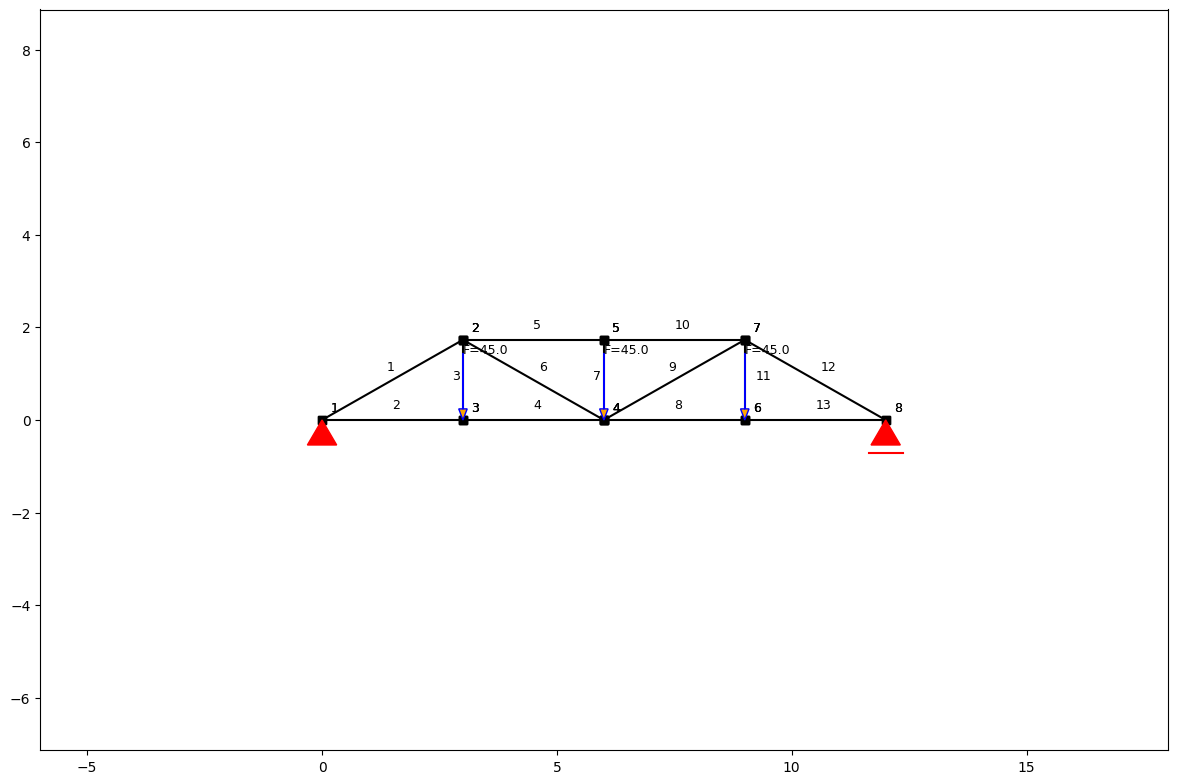

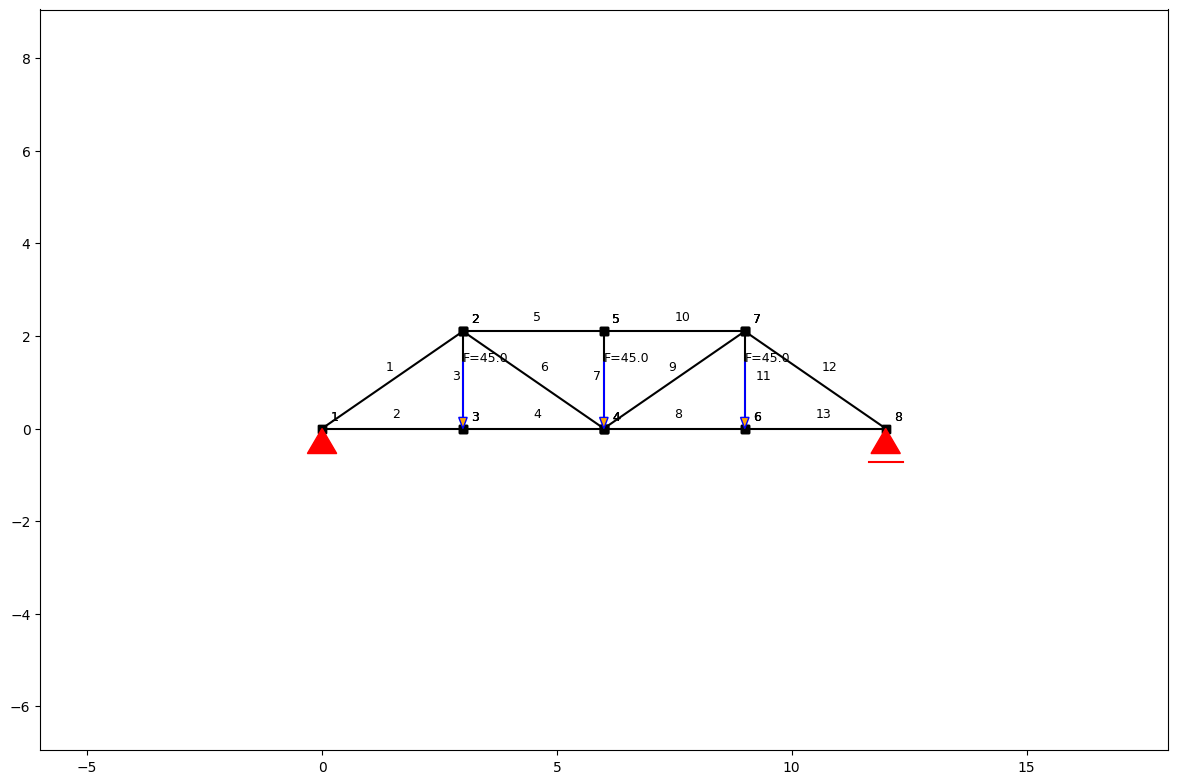

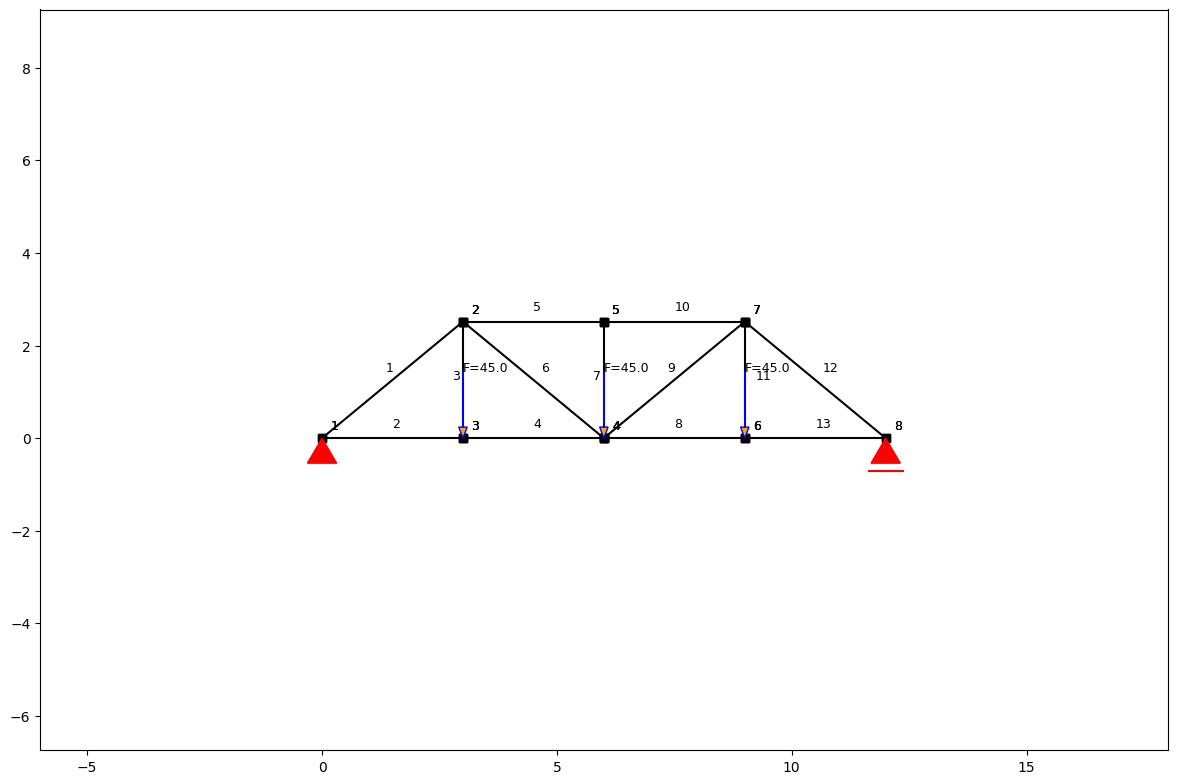

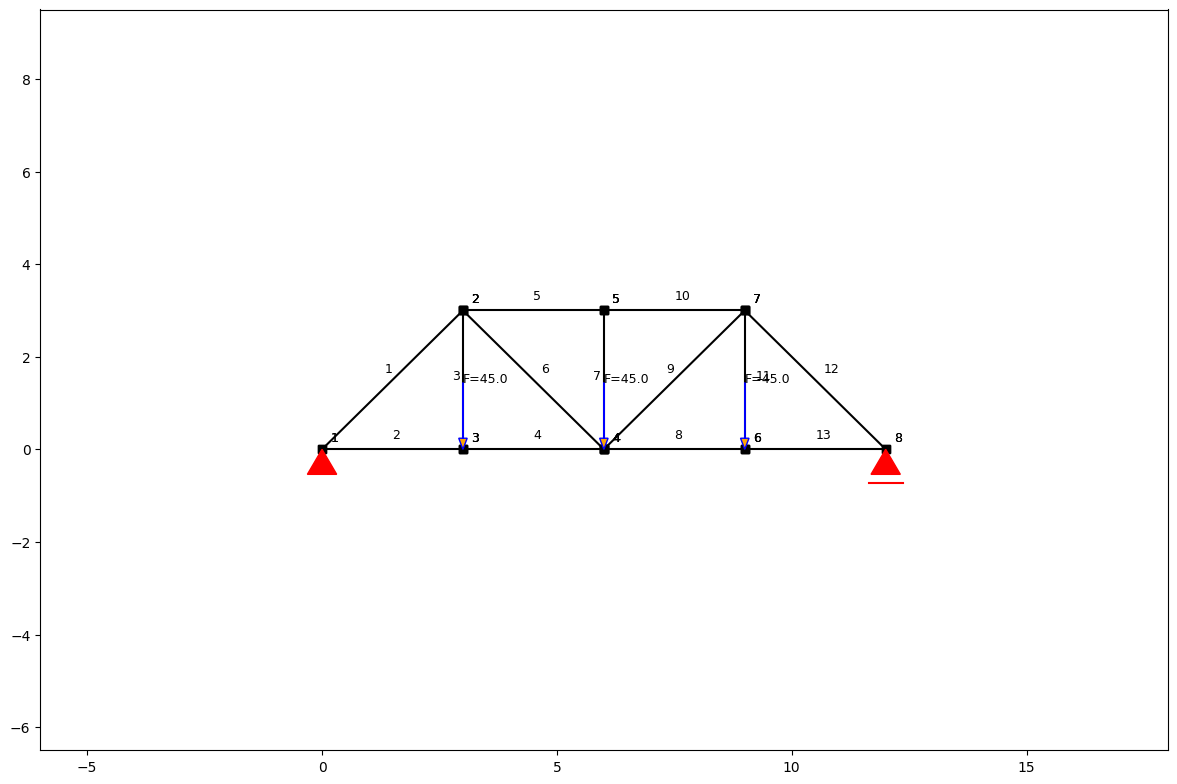

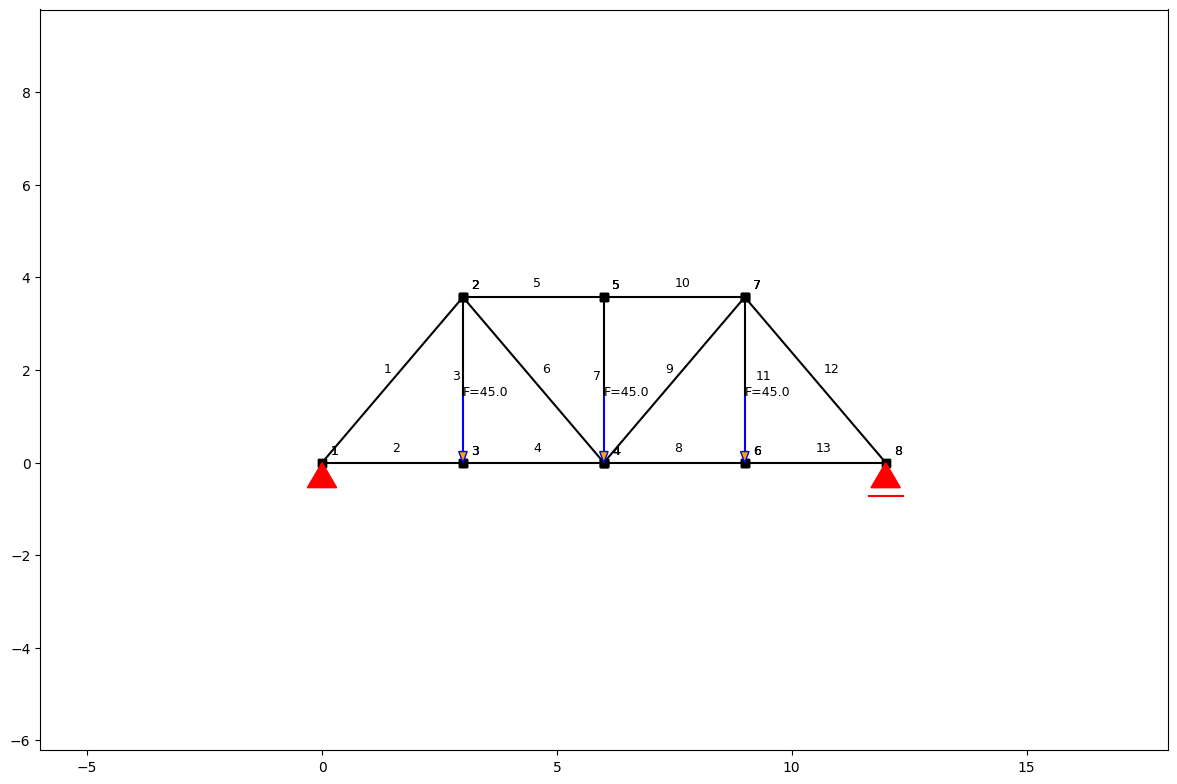

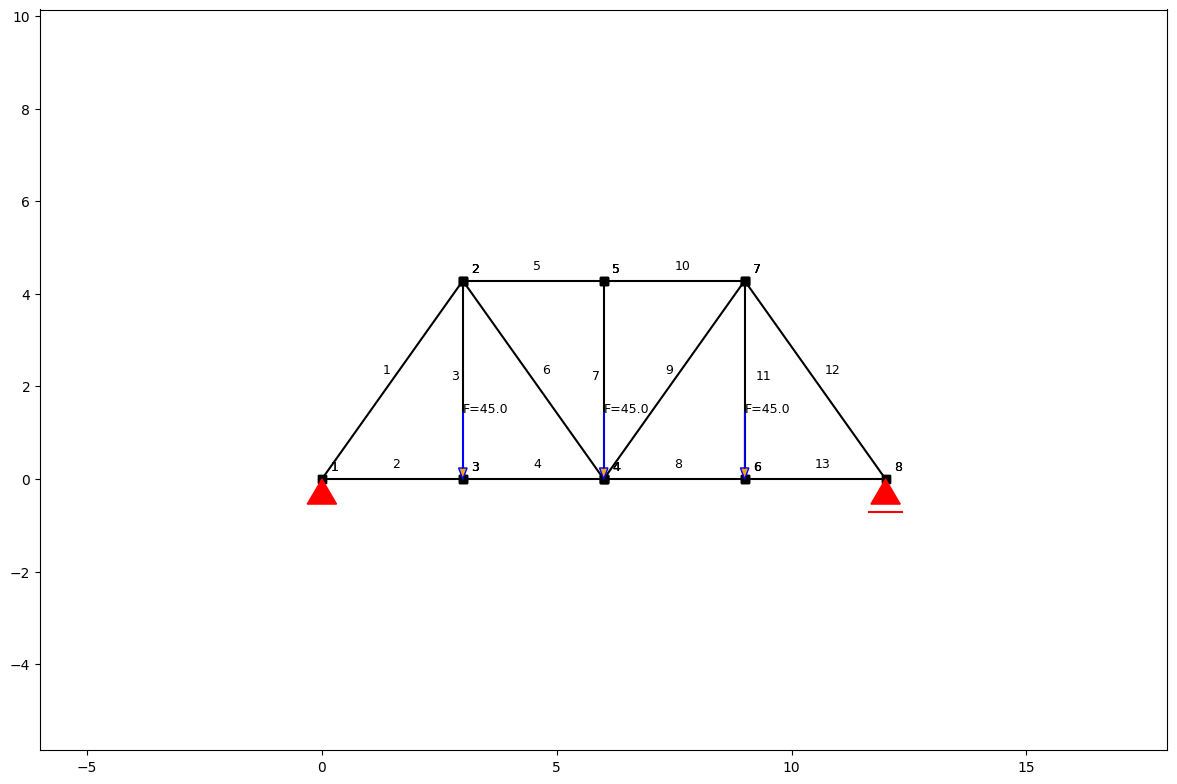

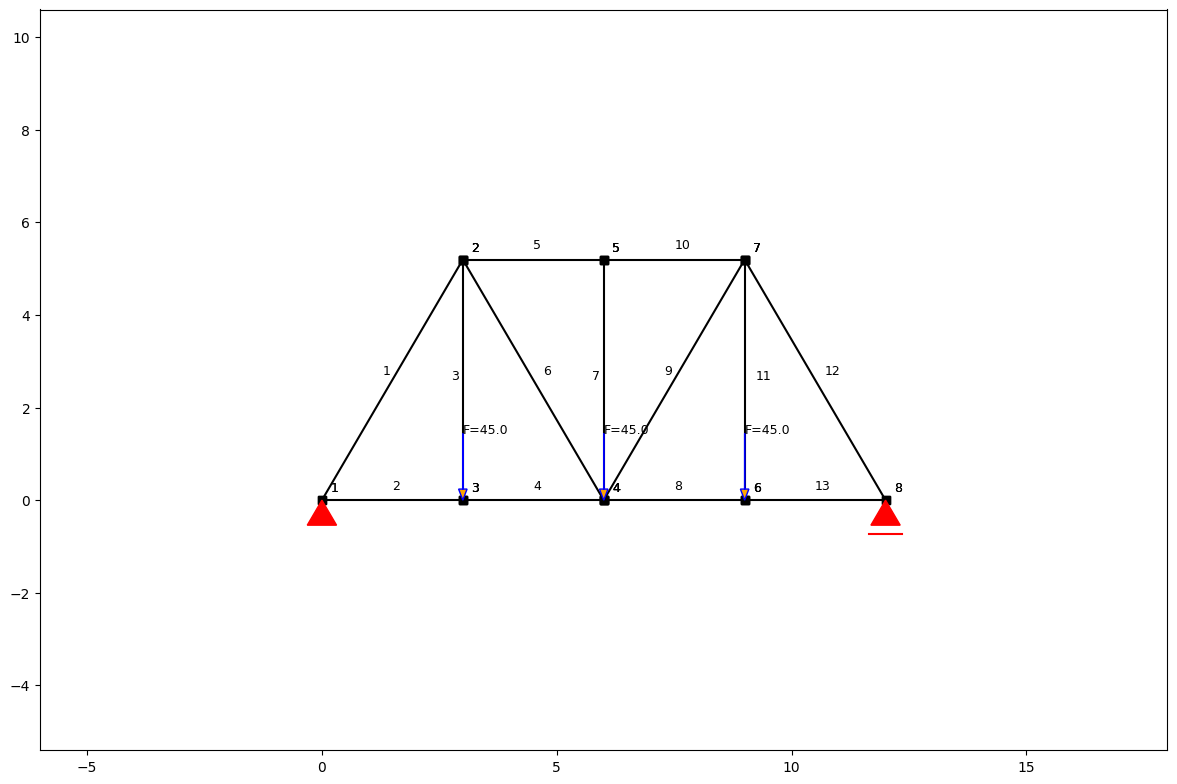

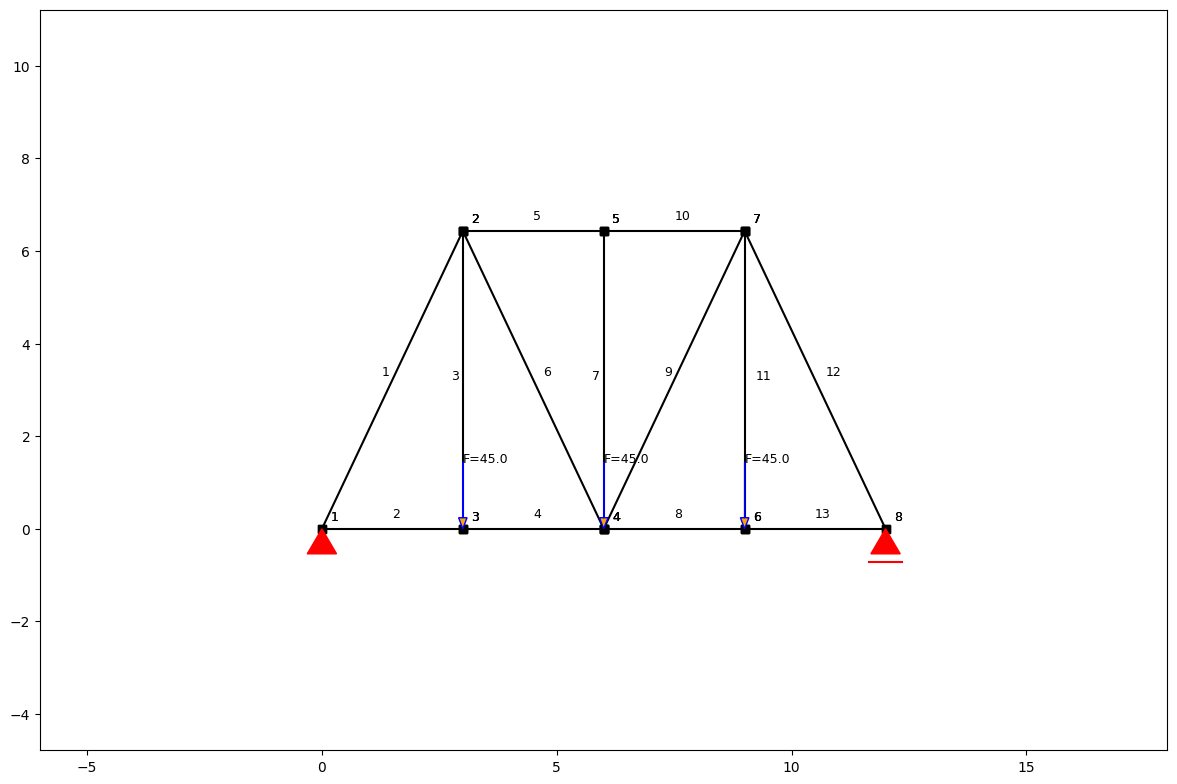

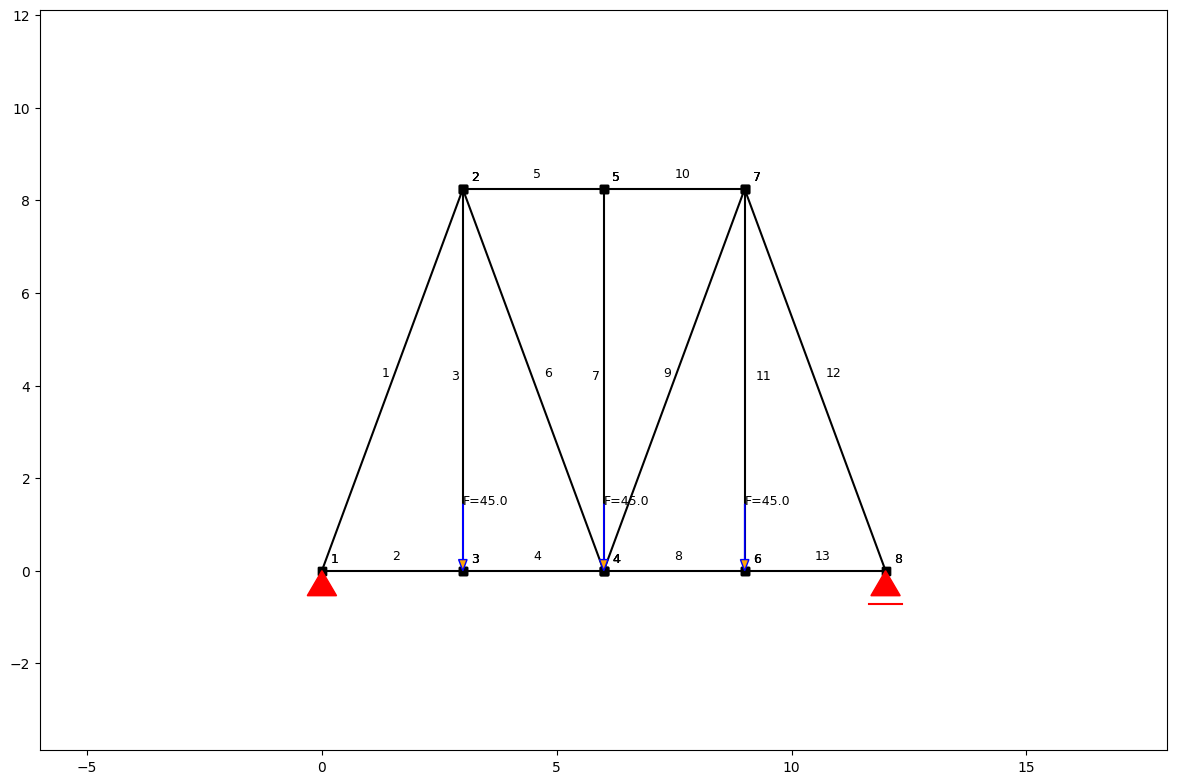

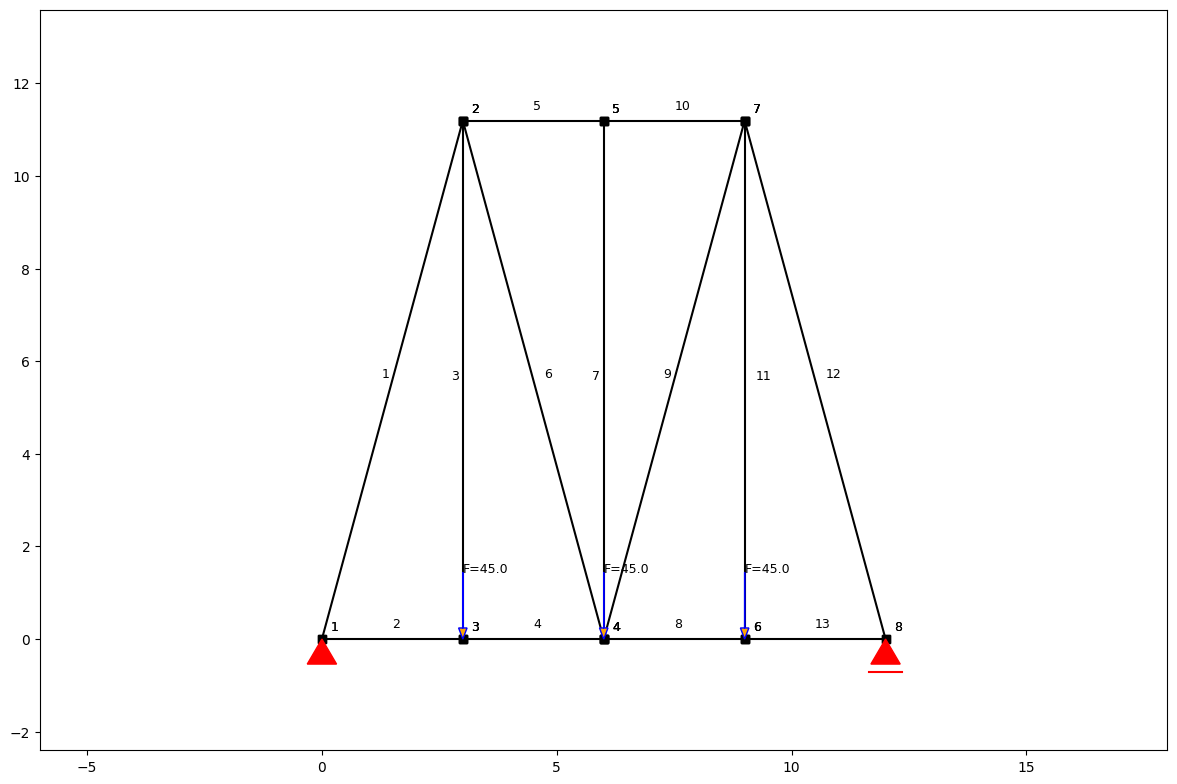

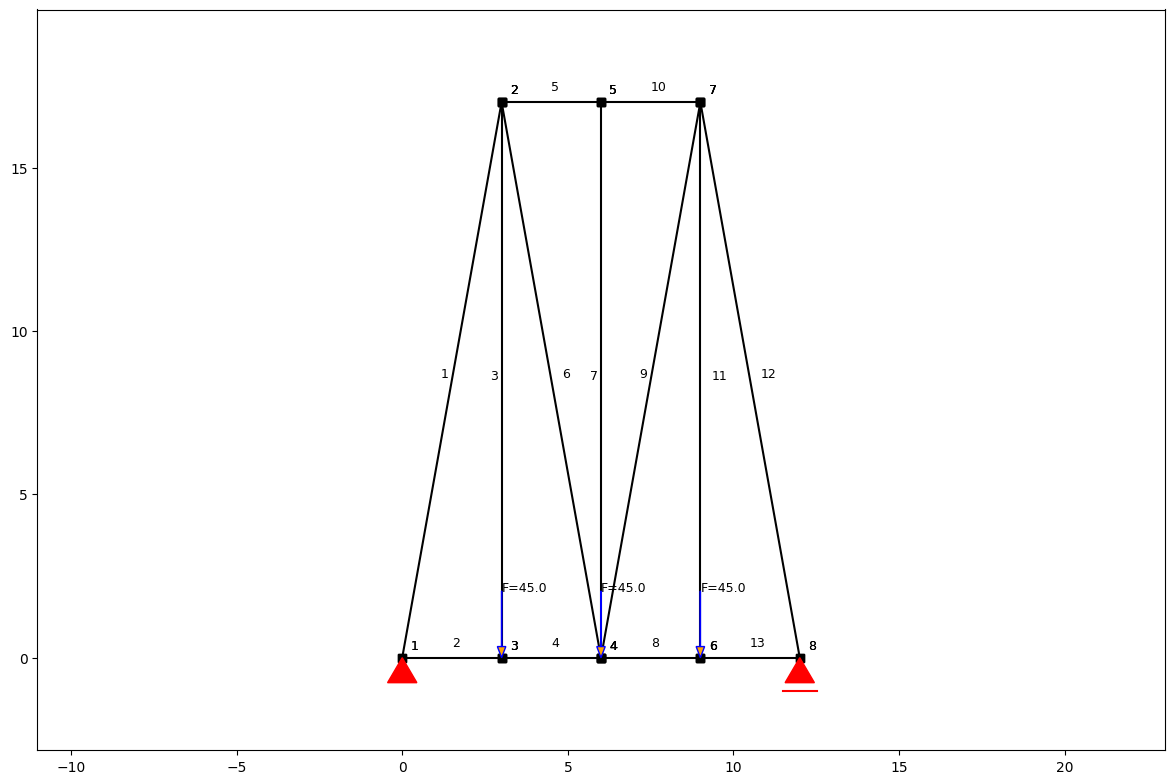

In [140]:
thetas = [20,25,30,35,40,45,50,55,60,65,70,75,80]
results = []
for theta in thetas:
  ss = SystemElements()
  x_a,y_a = 0 , 0
  x_b,y_b = 3 , 3*np.tan(theta*np.pi/180)
  x_c, y_c = 3, 0
  x_d, y_d = 6, 3*np.tan(theta*np.pi/180)
  x_e,y_e = 6,0
  x_f , y_f = 9,3*np.tan(theta*np.pi/180)
  x_g, y_g = 9,0
  x_h, y_h = 12,0
  nodes = {
    'A' : [x_a ,y_a],
    'B' : [x_b,y_b],
    'C' : [x_c, y_c],
    'D' : [x_d,y_d],
    'E' : [x_e,y_e],
    'F' : [x_f,y_f],
    'G' : [x_g,y_g],
    'H' : [x_h, y_h]
  }
  conec = [
      ['A','B'],['A', 'C'],['C','B'], ['C', 'E'],['B', 'D'], ['E', 'B'],['E','D'],['E' , 'G'],['E','F'],['D','F'],['F','G'],['F','H'],['H','G']
  ]
  load = {'C' :  (0, -45, 0), 'E' : (0,-45,0), 'G' : (0,-45,0)}

  support = {'A' : (1,1,0), 'H' : (0,1,0)}

  for n1, n2 in conec:
    coord1 = nodes[n1]
    coord2 = nodes[n2]
    ss.add_truss_element(location = [coord1,coord2])

  for name ,  (fx, fy, M) in load.items():
      node_coord = nodes[name]
      node_id = ss.find_node_id(node_coord)
      ss.point_load(node_id = node_id , Fx =fx ,Fy = fy)

  for s in support:
      node_id = ss.find_node_id(nodes[s])
      restr = support[s]
      if restr == (1,1,1):
          ss . add_support_fixed (node_id = node_id )
      elif restr == (1,1,0):
          ss.add_support_hinged(node_id = node_id)
      else:
        if restr [0] == 1:
          ss.add_support_roll(node_id = node_id,direction = 1)
        if restr [1] == 1:
          ss.add_support_roll(node_id = node_id,direction = 2)
  ss.solve()
  ss.show_structure()
  results.append(ss.get_element_results())

In [141]:
results

[[{'id': 1,
   'length': 3.192533254623413,
   'alpha': 0.34906585542411994,
   'umax': np.float64(-0.018878010478745565),
   'umin': np.float64(-0.03563364108118244),
   'u': None,
   'wtotmax': np.float64(0.0),
   'wtotmin': np.float64(0.4768954135649914),
   'wtot': None,
   'Nmin': np.float64(-197.3567942861486),
   'Nmax': np.float64(-197.3567942861486),
   'N': None},
  {'id': 2,
   'length': 3.0,
   'alpha': 0.0,
   'umax': np.float64(0.029567708426184718),
   'umin': np.float64(0.015664397253997542),
   'u': None,
   'wtotmax': np.float64(0.0),
   'wtotmin': np.float64(0.465777231999428),
   'wtot': None,
   'Nmin': np.float64(185.4547229134521),
   'Nmax': np.float64(185.4547229134521),
   'N': None},
  {'id': 3,
   'length': 1.091910719871521,
   'alpha': 1.5707963267948966,
   'umax': np.float64(0.0009504385275327099),
   'umin': np.float64(0.0005035238594138809),
   'u': None,
   'wtotmax': np.float64(0.037090944582690445),
   'wtotmin': np.float64(0.12363648194230081),
   

In [142]:
n_thetas = len(thetas) 
n_barras = len(conec)

normal = np.zeros(shape = (13,13))

lengths = np.zeros(shape = (13,13))

for i in range(n_thetas):
  for j in range(n_barras):
    normal[i][j] = results[i][j]["Nmax"]
    lengths[i][j] = results[i][j]["length"]

In [143]:
length_df = pd.DataFrame(data = lengths)
length_df.index = [f"theta = {theta}" for theta in thetas]

normal_df = pd.DataFrame(data = normal)
normal_df.index = [f"theta = {theta}" for theta in thetas]

diametros = np.sqrt(4*np.abs(normal * 1e3)/ (140e6 * np.pi))

diametros_df = pd.DataFrame(data = diametros)
diametros_df.index = [f"theta = {theta}" for theta in thetas]

volume = (np.pi*diametros**2/4)*lengths
volumes_df = pd.DataFrame(data = volume)
volumes_df.index = [f"{theta}" for theta in thetas]

p_esp = 78000*volumes_df
pesp_df = pd.DataFrame(data = p_esp)
pesp_df.index = [f"{theta}" for theta in thetas]

pesos = pesp_df.sum(axis = 1)
pesos

20    3057.348227
25    2468.603842
30    2084.399448
35    1819.833475
40    1633.590188
45    1504.285687
50    1421.393263
55    1381.821304
60    1389.599634
65    1458.807293
70    1623.158032
75    1966.371753
80    2745.040820
dtype: float64

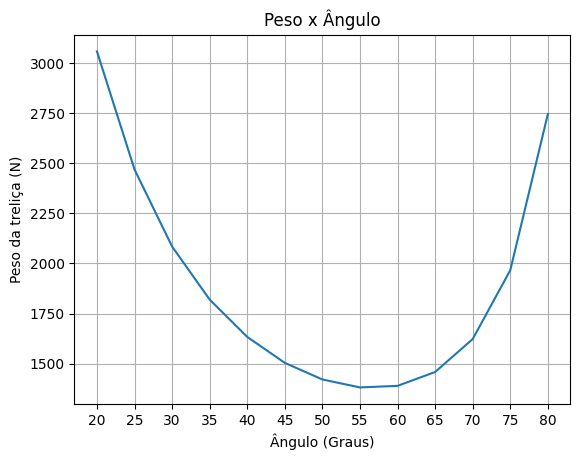

In [144]:
plt.plot(pesos)
plt.title("Peso x Ângulo")
plt.xlabel("Ângulo (Graus)")
plt.ylabel("Peso da treliça (N)")
plt.grid()
plt.show()


In [145]:
thetas = [50,51,52,53,54,55,56,57,58,59,60]
results = []
for theta in thetas:
  ss = SystemElements()
  x_a,y_a = 0 , 0
  x_b,y_b = 3 , 3*np.tan(theta*np.pi/180)
  x_c, y_c = 3, 0
  x_d, y_d = 6, 3*np.tan(theta*np.pi/180)
  x_e,y_e = 6,0
  x_f , y_f = 9,3*np.tan(theta*np.pi/180)
  x_g, y_g = 9,0
  x_h, y_h = 12,0
  nodes = {
    'A' : [x_a ,y_a],
    'B' : [x_b,y_b],
    'C' : [x_c, y_c],
    'D' : [x_d,y_d],
    'E' : [x_e,y_e],
    'F' : [x_f,y_f],
    'G' : [x_g,y_g],
    'H' : [x_h, y_h]
  }
  conec = [
      ['A','B'],['A', 'C'],['C','B'], ['C', 'E'],['B', 'D'], ['E', 'B'],['E','D'],['E' , 'G'],['E','F'],['D','F'],['F','G'],['F','H'],['H','G']
  ]
  load = {'C' :  (0, -45, 0), 'E' : (0,-45,0), 'G' : (0,-45,0)}

  support = {'A' : (1,1,0), 'H' : (0,1,0)}

  for n1, n2 in conec:
    coord1 = nodes[n1]
    coord2 = nodes[n2]
    ss.add_truss_element(location = [coord1,coord2])

  for name ,  (fx, fy, M) in load.items():
      node_coord = nodes[name]
      node_id = ss.find_node_id(node_coord)
      ss.point_load(node_id = node_id , Fx =fx ,Fy = fy)

  for s in support:
      node_id = ss.find_node_id(nodes[s])
      restr = support[s]
      if restr == (1,1,1):
          ss . add_support_fixed (node_id = node_id )
      elif restr == (1,1,0):
          ss.add_support_hinged(node_id = node_id)
      else:
        if restr [0] == 1:
          ss.add_support_roll(node_id = node_id,direction = 1)
        if restr [1] == 1:
          ss.add_support_roll(node_id = node_id,direction = 2)
  ss.solve()
  results.append(ss.get_element_results())

In [146]:
n_thetas = len(thetas) 
n_barras = len(conec)

normal = np.zeros(shape = (n_thetas,n_barras))

lengths = np.zeros(shape = (n_thetas,n_barras))

for i in range(n_thetas):
  for j in range(n_barras):
    normal[i][j] = results[i][j]["Nmax"]
    lengths[i][j] = results[i][j]["length"]

length_df = pd.DataFrame(data = lengths)
length_df.index = [f"theta = {theta}" for theta in thetas]

normal_df = pd.DataFrame(data = normal)
normal_df.index = [f"theta = {theta}" for theta in thetas]

diametros = np.sqrt(4*np.abs(normal * 1e3)/ (140e6 * np.pi))

diametros_df = pd.DataFrame(data = diametros)
diametros_df.index = [f"theta = {theta}" for theta in thetas]

volume = (np.pi*diametros**2/4)*lengths
volumes_df = pd.DataFrame(data = volume)
volumes_df.index = [f"{theta}" for theta in thetas]

p_esp = 78000*volumes_df
pesp_df = pd.DataFrame(data = p_esp)
pesp_df.index = [f"{theta}" for theta in thetas]

pesos = pesp_df.sum(axis = 1)

peso_minimo = np.min(pesos.values)
angulo_minimo_mask = pesos[pesos.index] == peso_minimo
angulo_minimo = pesos[angulo_minimo_mask]

pesos

50    1421.393263
51    1409.994071
52    1400.313106
53    1392.368802
54    1386.190783
55    1381.821304
56    1379.316046
57    1378.745249
58    1380.195592
59    1383.771775
60    1389.599634
dtype: float64

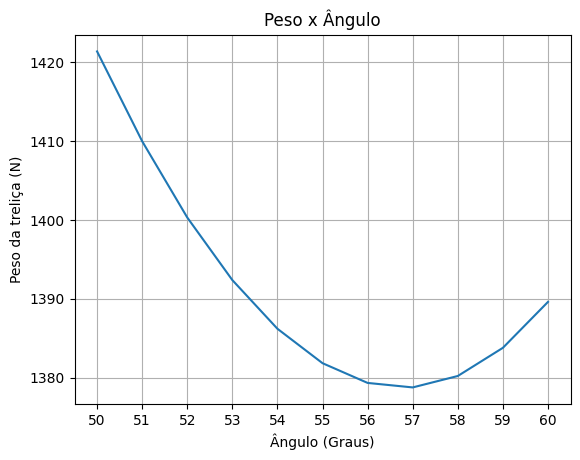

In [147]:
plt.plot(pesos)
plt.title("Peso x Ângulo")
plt.xlabel("Ângulo (Graus)")
plt.ylabel("Peso da treliça (N)")
plt.grid()
plt.show()


In [149]:
print(f"Valor ótimo do ângulo: {angulo_minimo.index[0]}°")
print(f"Peso mínimo: {peso_minimo:.2f} N")

Valor ótimo do ângulo: 57°
Peso mínimo: 1378.75 N
